In [17]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns

from tensorflow import keras
from keras import layers
from keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, accuracy_score,
    precision_score, recall_score, f1_score
)


#install drive
from google.colab import drive
drive.mount('/content/drive')

#folder structure
BASE_PATH = "/content/drive/MyDrive/CrossValidation/OldModels"
print(BASE_PATH)

TRAIN_DIR = "/content/drive/MyDrive/kaggle/train"
TEST_DIR  = "/content/drive/MyDrive/kaggle/test"

folders = [
    "models",
    "histories",
    "metrics",
    "plots/training",
    "plots/confusion_matrix",
    "plots/roc",
    "plots/metrics"
]

for f in folders:
    os.makedirs(os.path.join(BASE_PATH, f), exist_ok=True)

print(BASE_PATH)
print(os.listdir("/content/drive/MyDrive"))
print(os.listdir(BASE_PATH))


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10
N_SPLITS = 3
SEED = 42
THRESHOLD = 0.5

tf.keras.utils.set_random_seed(SEED)

# load file path
class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("Class:", class_names)

filepaths = []
labels = []

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(TRAIN_DIR, class_name)
    files = sorted([
        os.path.join(class_dir, f)
        for f in os.listdir(class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    filepaths.extend(files)
    labels.extend([idx] * len(files))

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total images:", len(filepaths))
print("Label distribution:", {class_names[i]: int((labels == i).sum()) for i in range(len(class_names))})


test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = test_ds.map(
    lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# build model
def build_model(model_name):
    if model_name == "vgg16":
        base_model = keras.applications.VGG16(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    elif model_name == "resnet":
        base_model = keras.applications.ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    elif model_name == "densenet":
        base_model = keras.applications.DenseNet121(
            weights="imagenet",
            include_top=False,
            input_shape=(224, 224, 3)
        )
    else:
        raise ValueError("model_name must be one of: vgg16, resnet, densenet")

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


# DATASET PIPELINE FOR K-FOLD

def decode_and_resize(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    label = tf.cast(label, tf.float32)
    return img, label

def augment_data(img, label):
    img = data_augmentation(img, training=True)
    return img, label

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

# evalutation
def evaluate_model(model, dataset, threshold=0.5):
    y_true = []
    y_pred_prob = []

    for x, y in dataset:
        preds = model(x, training=False).numpy().flatten()
        y_true.extend(y.numpy().flatten())
        y_pred_prob.extend(preds)

    y_true = np.array(y_true).astype(int)
    y_pred_prob = np.array(y_pred_prob)
    y_pred_bin = (y_pred_prob > threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred_bin)
    tn, fp, fn, tp = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred_bin)
    sensitivity = recall_score(y_true, y_pred_bin, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y_true, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true, y_pred_bin, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_prob)

    return {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "auc": auc,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

def plot_confusion_matrix(cm, title, save_path):
    plt.figure(figsize=(5.5, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

def plot_roc_curve(y_true, y_prob, title, save_path):
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/CrossValidation/OldModels
/content/drive/MyDrive/CrossValidation/OldModels
['Colab Notebooks', 'kaggle', 'results5', 'results10', 'resultsResnetOPT1', 'resultsVgg16DensenetOPT1', 'GradCam', 'materiali tesi vari', 'CrossValidation', 'Sacilotto Greta Tesi Triennaleee.docx']
['models', 'histories', 'metrics (2)', 'plots', 'metrics']
Class: ['benign', 'malignant']
Total images: 2637
Label distribution: {'benign': 1440, 'malignant': 1197}
Found 660 files belonging to 2 classes.



3-FOLD CROSS VALIDATION - VGG16

----------------------------------------------------------------------
VGG16 - Fold 1/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.5945 - loss: 0.6647
Epoch 1: val_loss improved from None to 0.53025, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/vgg16_fold1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/vgg16_fold1_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 589s 4s/step - accuracy: 0.6428 - loss: 0.6262 - val_accuracy: 0.7702 - val_loss: 0.5302
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7533 - loss: 0.5354
Epoch 2: val_loss improved from 0.53025 to 0.48626, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/vgg16_fold1_best.keras

Epoch 2: finished 

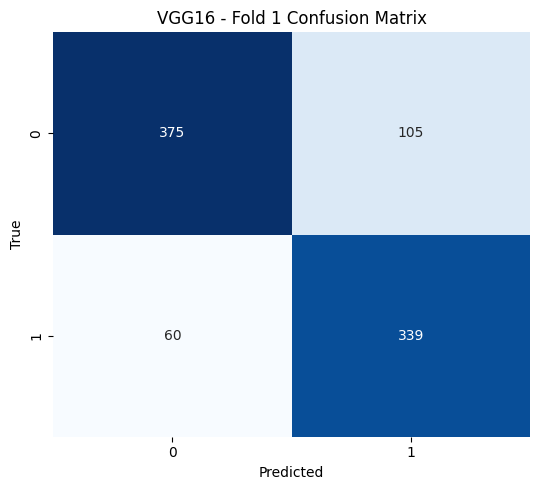

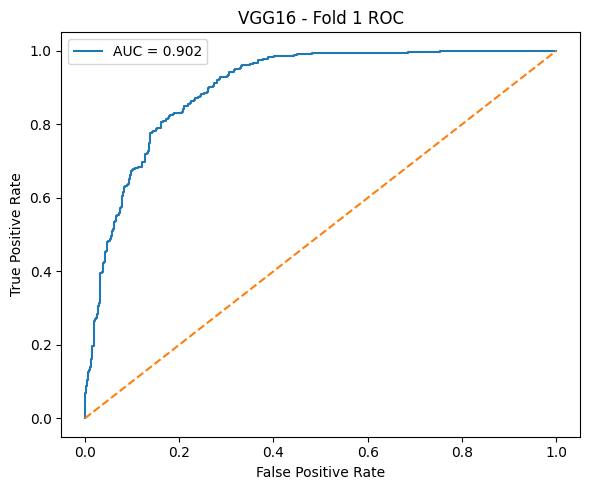


Fold 1 metrics:
{'accuracy': 0.8122866894197952, 'sensitivity': 0.849624060150376, 'specificity': np.float64(0.78125), 'precision': 0.7635135135135135, 'f1': 0.8042704626334519, 'auc': np.float64(0.9015037593984961), 'tn': 375, 'fp': 105, 'fn': 60, 'tp': 339, 'fold': 1, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 10, 'best_val_loss': 0.39933857321739197}

----------------------------------------------------------------------
VGG16 - Fold 2/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.5375 - loss: 0.6905
Epoch 1: val_loss improved from None to 0.54163, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/vgg16_fold2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/vgg16_fold2_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 41s 565ms/step - accuracy: 0.6274 - loss: 0.6293 - val_accuracy: 0

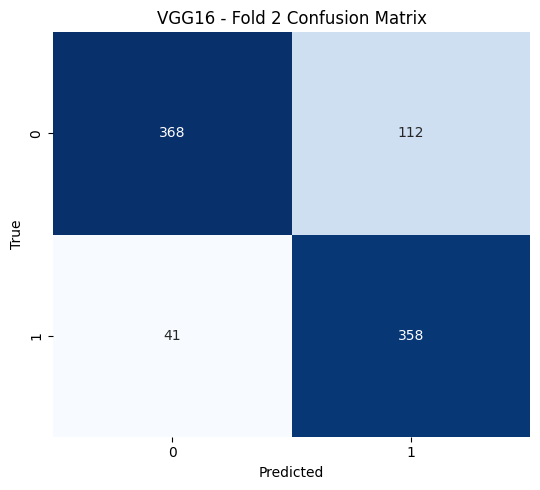

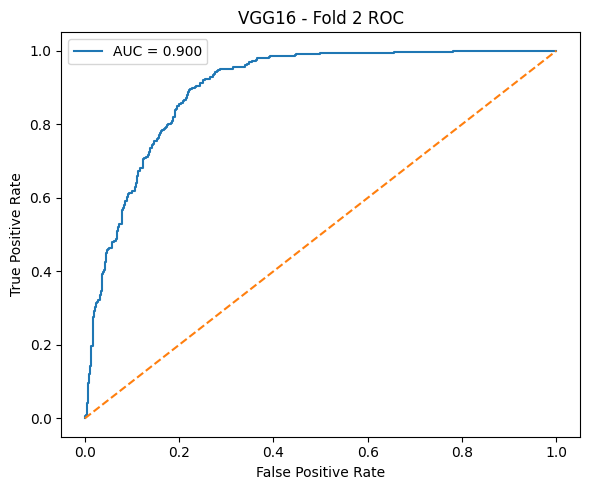


Fold 2 metrics:
{'accuracy': 0.825938566552901, 'sensitivity': 0.8972431077694235, 'specificity': np.float64(0.7666666666666667), 'precision': 0.7617021276595745, 'f1': 0.8239355581127733, 'auc': np.float64(0.900203634085213), 'tn': 368, 'fp': 112, 'fn': 41, 'tp': 358, 'fold': 2, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 10, 'best_val_loss': 0.4084189236164093}

----------------------------------------------------------------------
VGG16 - Fold 3/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.5831 - loss: 0.6825
Epoch 1: val_loss improved from None to 0.54306, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/vgg16_fold3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/vgg16_fold3_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 39s 566ms/step - accuracy: 0.6297 - loss: 0.6379 - val_ac

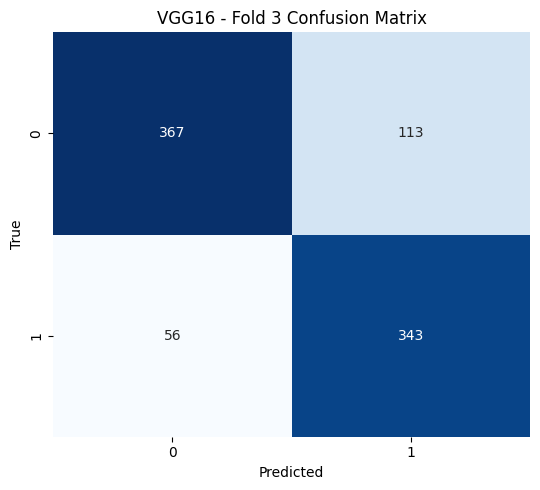

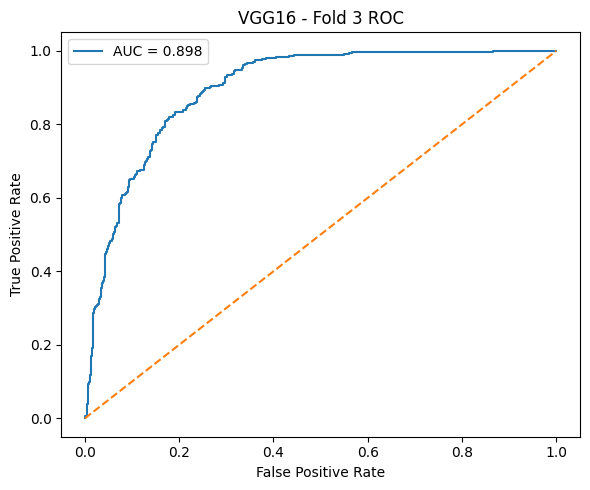


Fold 3 metrics:
{'accuracy': 0.8077360637087599, 'sensitivity': 0.8596491228070176, 'specificity': np.float64(0.7645833333333333), 'precision': 0.7521929824561403, 'f1': 0.8023391812865497, 'auc': np.float64(0.897780910609858), 'tn': 367, 'fp': 113, 'fn': 56, 'tp': 343, 'fold': 3, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 10, 'best_val_loss': 0.4069189131259918}

Saved: /content/drive/MyDrive/CrossValidation/OldModels/metrics/vgg16_3fold_cv_results.csv
      accuracy  sensitivity  specificity  precision        f1       auc
mean  0.815320     0.868839     0.770833   0.759136  0.810182  0.899829
std   0.009473     0.025104     0.009081   0.006081  0.011950  0.001889

3-FOLD CROSS VALIDATION - RESNET

----------------------------------------------------------------------
RESNET - Fold 1/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━

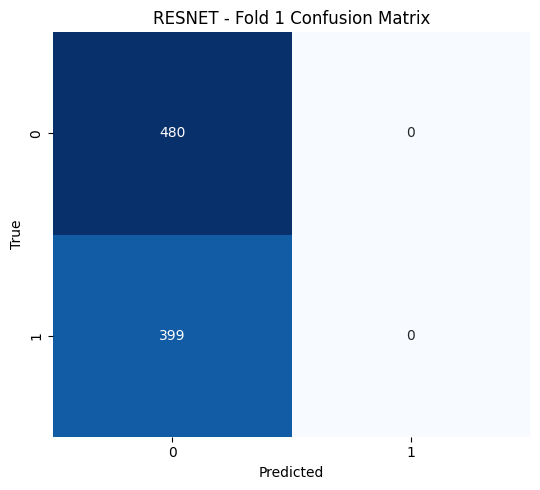

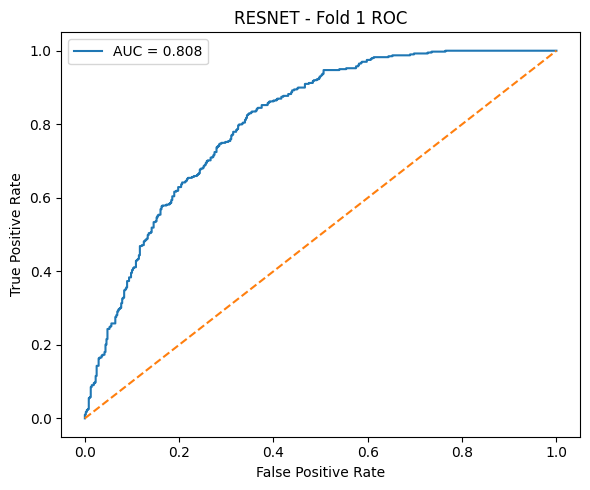


Fold 1 metrics:
{'accuracy': 0.5460750853242321, 'sensitivity': 0.0, 'specificity': np.float64(1.0), 'precision': 0.0, 'f1': 0.0, 'auc': np.float64(0.8077929197994989), 'tn': 480, 'fp': 0, 'fn': 399, 'tp': 0, 'fold': 1, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 5, 'best_val_loss': 0.6837083101272583}

----------------------------------------------------------------------
RESNET - Fold 2/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.5113 - loss: 0.7619
Epoch 1: val_loss improved from None to 0.68576, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/resnet_fold2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/resnet_fold2_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 50s 600ms/step - accuracy: 0.5040 - loss: 0.7334 - val_accuracy: 0.5472 - val_loss: 0.6858
Epoch 2/10
55/55 ━━━━━━━━

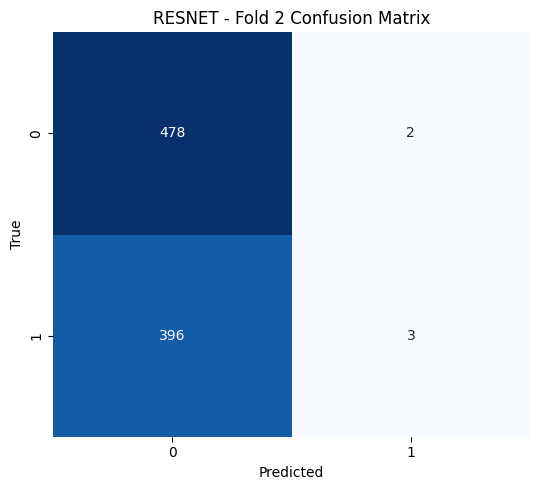

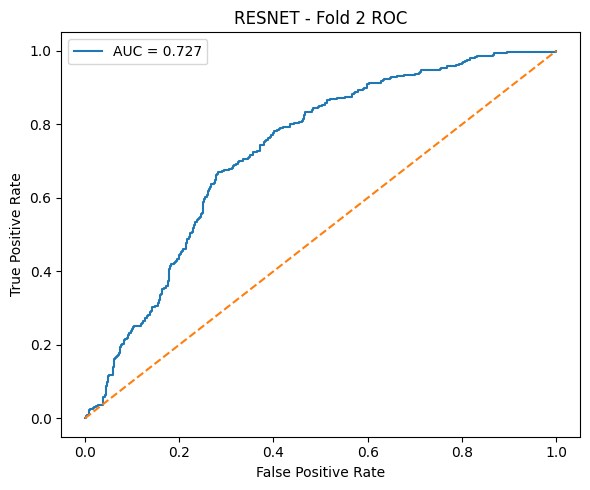


Fold 2 metrics:
{'accuracy': 0.5472127417519909, 'sensitivity': 0.007518796992481203, 'specificity': np.float64(0.9958333333333333), 'precision': 0.6, 'f1': 0.01485148514851485, 'auc': np.float64(0.7266551796157059), 'tn': 478, 'fp': 2, 'fn': 396, 'tp': 3, 'fold': 2, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 4, 'best_val_loss': 0.6857602596282959}

----------------------------------------------------------------------
RESNET - Fold 3/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.5164 - loss: 0.7427
Epoch 1: val_loss improved from None to 0.68567, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/resnet_fold3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/resnet_fold3_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 51s 611ms/step - accuracy: 0.5142 - loss: 0.7193 - val_accuracy: 0.5

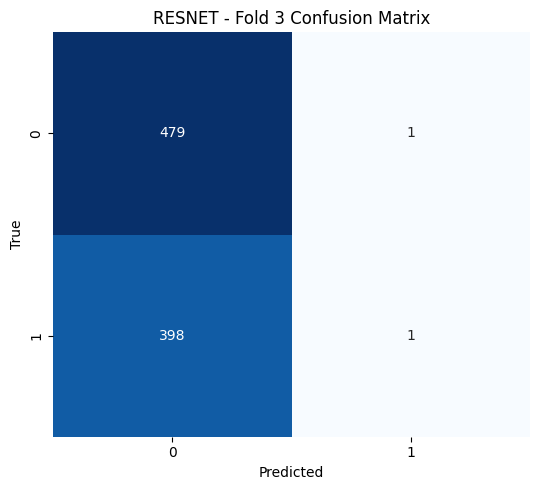

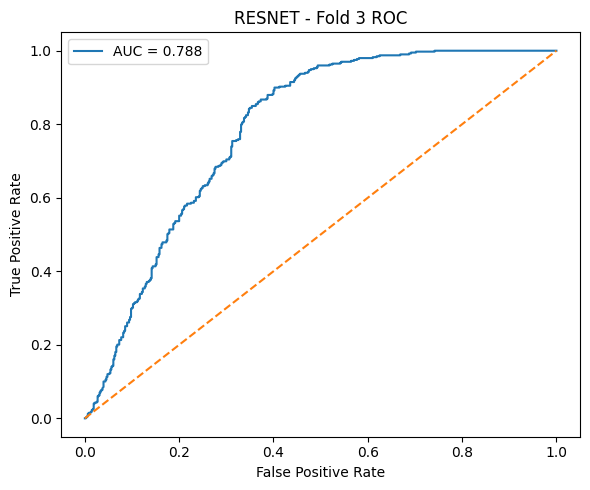


Fold 3 metrics:
{'accuracy': 0.5460750853242321, 'sensitivity': 0.002506265664160401, 'specificity': np.float64(0.9979166666666667), 'precision': 0.5, 'f1': 0.004987531172069825, 'auc': np.float64(0.7878263366750209), 'tn': 479, 'fp': 1, 'fn': 398, 'tp': 1, 'fold': 3, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 4, 'best_val_loss': 0.6856681108474731}

Saved: /content/drive/MyDrive/CrossValidation/OldModels/metrics/resnet_3fold_cv_results.csv
      accuracy  sensitivity  specificity  precision        f1       auc
mean  0.546454     0.003342     0.997917   0.366667  0.006613  0.774091
std   0.000657     0.003828     0.002083   0.321455  0.007558  0.042277

3-FOLD CROSS VALIDATION - DENSENET

----------------------------------------------------------------------
DENSENET - Fold 1/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 6

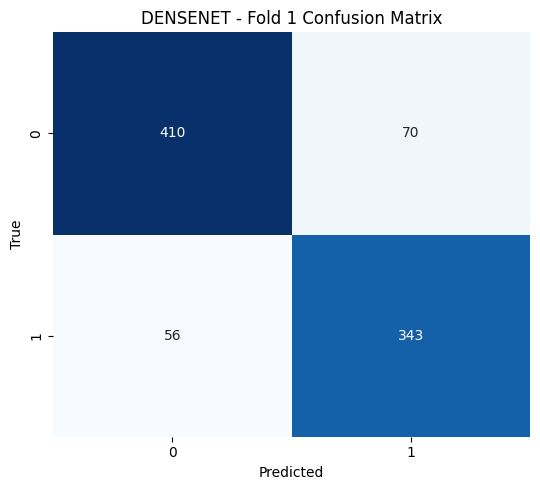

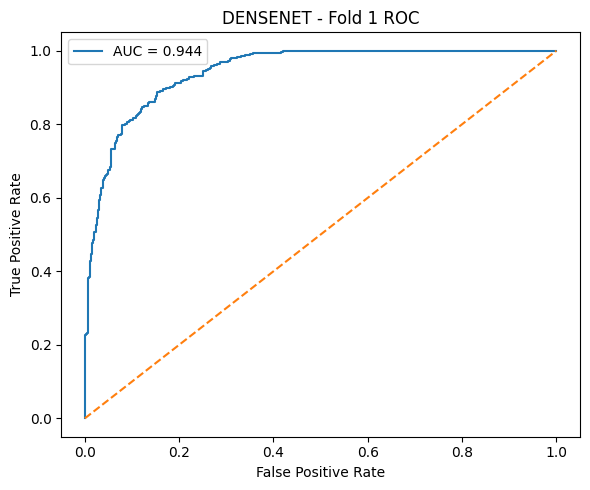


Fold 1 metrics:
{'accuracy': 0.856655290102389, 'sensitivity': 0.8596491228070176, 'specificity': np.float64(0.8541666666666666), 'precision': 0.8305084745762712, 'f1': 0.8448275862068966, 'auc': np.float64(0.9438596491228071), 'tn': 410, 'fp': 70, 'fn': 56, 'tp': 343, 'fold': 1, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 10, 'best_val_loss': 0.29728013277053833}

----------------------------------------------------------------------
DENSENET - Fold 2/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 553ms/step - accuracy: 0.7193 - loss: 0.5710
Epoch 1: val_loss improved from None to 0.40315, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/densenet_fold2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/densenet_fold2_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7577 - loss: 0.5100 -

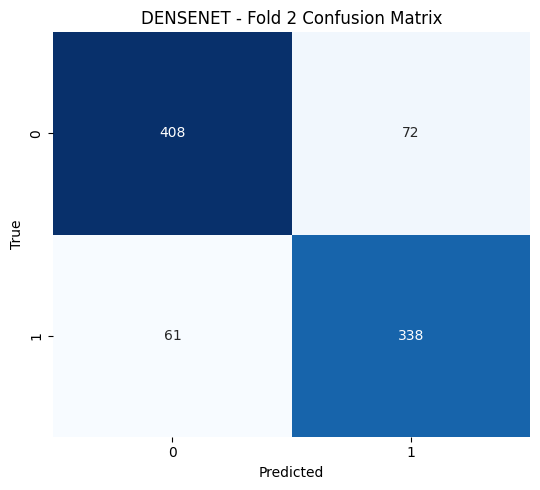

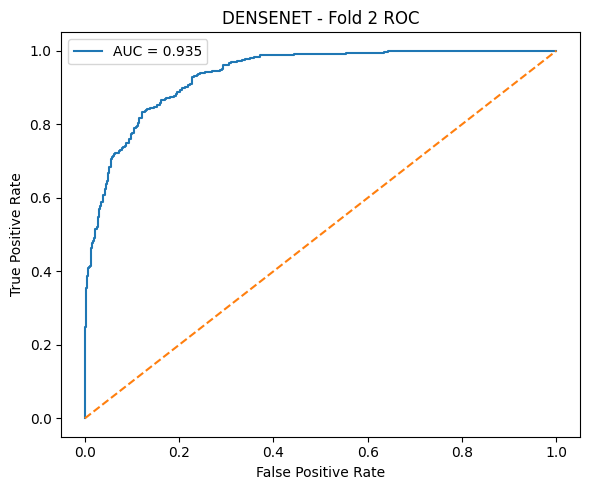


Fold 2 metrics:
{'accuracy': 0.8486916951080774, 'sensitivity': 0.8471177944862155, 'specificity': np.float64(0.85), 'precision': 0.824390243902439, 'f1': 0.8355995055624228, 'auc': np.float64(0.9353905597326649), 'tn': 408, 'fp': 72, 'fn': 61, 'tp': 338, 'fold': 2, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 10, 'best_val_loss': 0.32253846526145935}

----------------------------------------------------------------------
DENSENET - Fold 3/3
----------------------------------------------------------------------
Train samples: 1758
Validation samples: 879
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 557ms/step - accuracy: 0.7082 - loss: 0.5477
Epoch 1: val_loss improved from None to 0.40887, saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/densenet_fold3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/CrossValidation/OldModels/models/densenet_fold3_best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.7611 - loss: 0.4901 - val_accuracy:

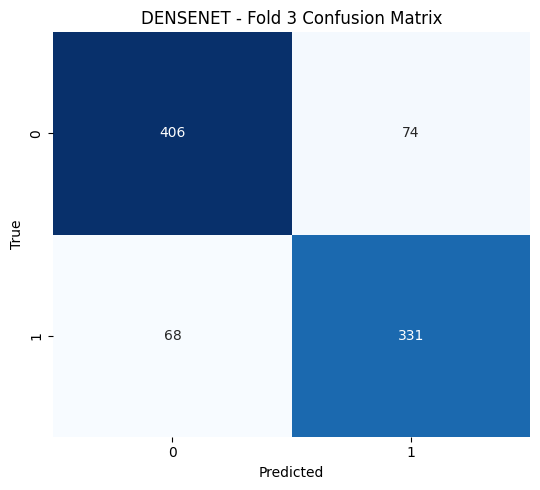

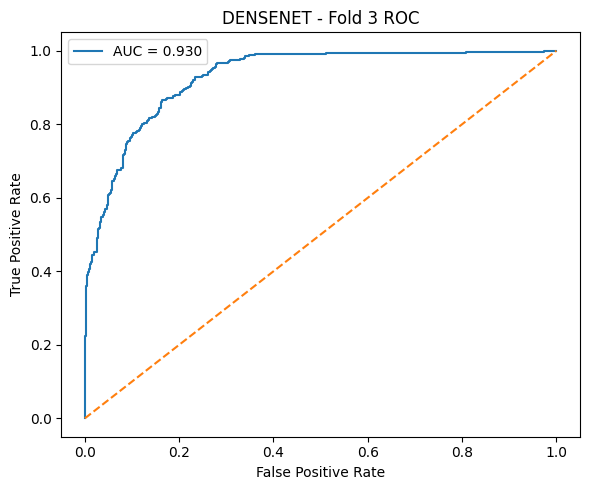


Fold 3 metrics:
{'accuracy': 0.838452787258248, 'sensitivity': 0.8295739348370927, 'specificity': np.float64(0.8458333333333333), 'precision': 0.817283950617284, 'f1': 0.8233830845771144, 'auc': np.float64(0.9296261487050961), 'tn': 406, 'fp': 74, 'fn': 68, 'tp': 331, 'fold': 3, 'n_train': 1758, 'n_val': 879, 'epochs_ran': 10, 'best_val_loss': 0.33114516735076904}

Saved: /content/drive/MyDrive/CrossValidation/OldModels/metrics/densenet_3fold_cv_results.csv
      accuracy  sensitivity  specificity  precision        f1       auc
mean  0.847933     0.845447     0.850000   0.824061  0.834603  0.936292
std   0.009125     0.015107     0.004167   0.006618  0.010757  0.007159


In [ ]:

#3-fold cross validation
models_to_run = ["vgg16", "resnet", "densenet"]
all_fold_results = {}
all_histories = {}

for model_name in models_to_run:
    print("\n" + "="*80)
    print(f"3-FOLD CROSS VALIDATION - {model_name.upper()}")
    print("="*80)

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

    fold_histories = {}
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(filepaths, labels), start=1):
        print("\n" + "-"*70)
        print(f"{model_name.upper()} - Fold {fold}/{N_SPLITS}")
        print("-"*70)

        tf.keras.backend.clear_session()

        X_train, X_val = filepaths[train_idx], filepaths[val_idx]
        y_train, y_val = labels[train_idx], labels[val_idx]

        print(f"Train samples: {len(X_train)}")
        print(f"Validation samples: {len(X_val)}")

        train_ds_fold = make_dataset(X_train, y_train, training=True)
        val_ds_fold = make_dataset(X_val, y_val, training=False)

        model = build_model(model_name)

        checkpoint_path = os.path.join(BASE_PATH, "models", f"{model_name}_fold{fold}_best.keras")
        history_path = os.path.join(BASE_PATH, "histories", f"{model_name}_fold{fold}_history.json")

        checkpoint = ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            mode="min",
            verbose=1
        )

        early_stopping = EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        )

        history = model.fit(
            train_ds_fold,
            validation_data=val_ds_fold,
            epochs=EPOCHS,
            callbacks=[checkpoint, early_stopping]
        )

        with open(history_path, "w") as f:
            json.dump(history.history, f, indent=4)

        fold_histories[f"fold_{fold}"] = history.history

        best_model = keras.models.load_model(checkpoint_path)
        metrics = evaluate_model(best_model, val_ds_fold, threshold=THRESHOLD)
        metrics["fold"] = fold
        metrics["n_train"] = len(X_train)
        metrics["n_val"] = len(X_val)
        metrics["epochs_ran"] = len(history.history.get("loss", []))
        metrics["best_val_loss"] = float(np.min(history.history.get("val_loss", [np.nan])))

        fold_results.append(metrics)

        cm = np.array([[metrics["tn"], metrics["fp"]], [metrics["fn"], metrics["tp"]]])
        cm_path = os.path.join(BASE_PATH, "plots", "confusion_matrix", f"{model_name}_fold{fold}_cm.png")
        plot_confusion_matrix(cm, f"{model_name.upper()} - Fold {fold} Confusion Matrix", cm_path)

        y_true_val = []
        y_prob_val = []
        for x, y in val_ds_fold:
            p = best_model(x, training=False).numpy().flatten()
            y_true_val.extend(y.numpy().flatten())
            y_prob_val.extend(p)

        y_true_val = np.array(y_true_val).astype(int)
        y_prob_val = np.array(y_prob_val)

        roc_path = os.path.join(BASE_PATH, "plots", "roc", f"{model_name}_fold{fold}_roc.png")
        plot_roc_curve(y_true_val, y_prob_val, f"{model_name.upper()} - Fold {fold} ROC", roc_path)

        print(f"\nFold {fold} metrics:")
        print(metrics)

    fold_results_df = pd.DataFrame(fold_results)
    fold_results_df = fold_results_df[
        ["fold", "n_train", "n_val", "epochs_ran", "best_val_loss",
         "accuracy", "sensitivity", "specificity", "precision", "f1", "auc", "tn", "fp", "fn", "tp"]
    ]

    model_metrics_path = os.path.join(BASE_PATH, "metrics", f"{model_name}_3fold_cv_results.csv")
    fold_results_df.to_csv(model_metrics_path, index=False)

    summary_df = fold_results_df[["accuracy", "sensitivity", "specificity", "precision", "f1", "auc"]].agg(["mean", "std"])
    summary_path = os.path.join(BASE_PATH, "metrics", f"{model_name}_3fold_cv_summary.csv")
    summary_df.to_csv(summary_path)

    print("\nSaved:", model_metrics_path)
    print(summary_df)

Cartella utilizzata:
/content/drive/MyDrive/CrossValidation/OldModels/metrics (2)



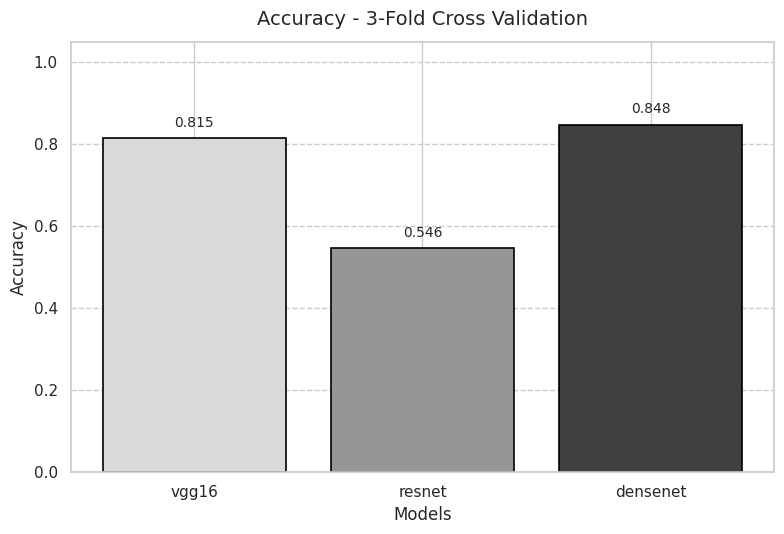

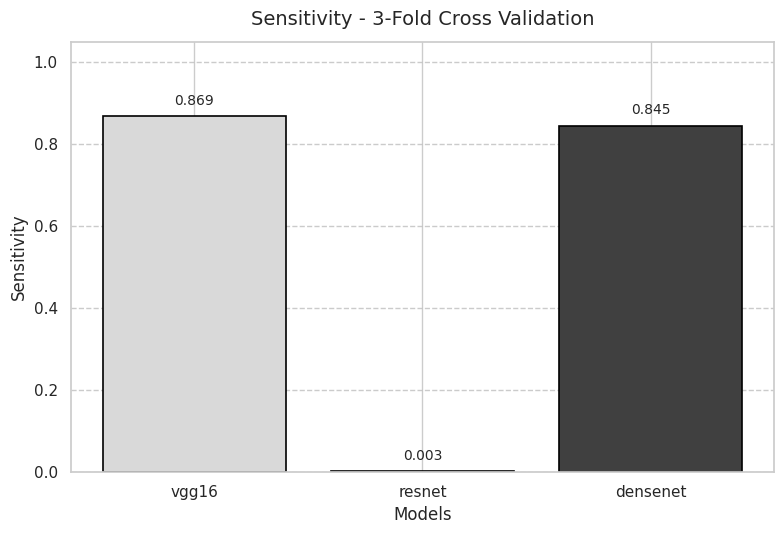

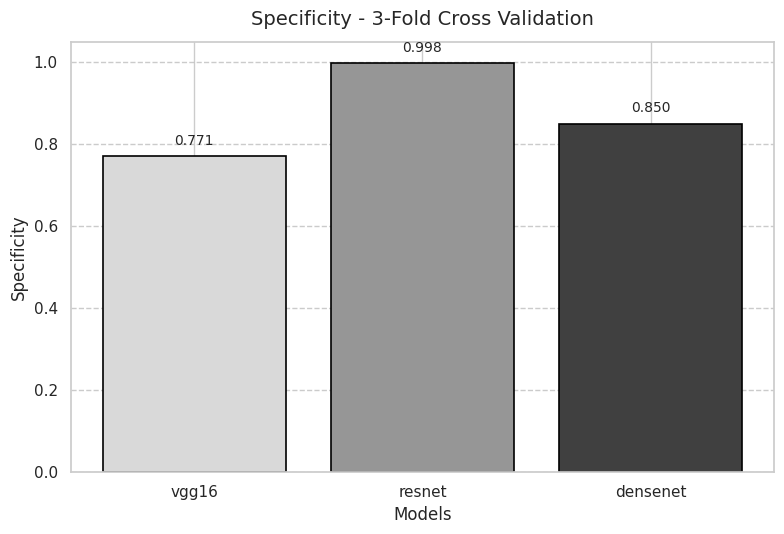

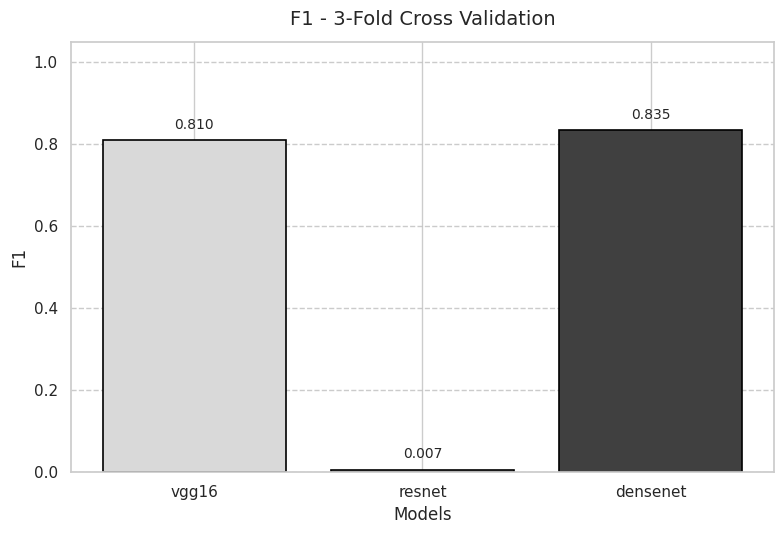

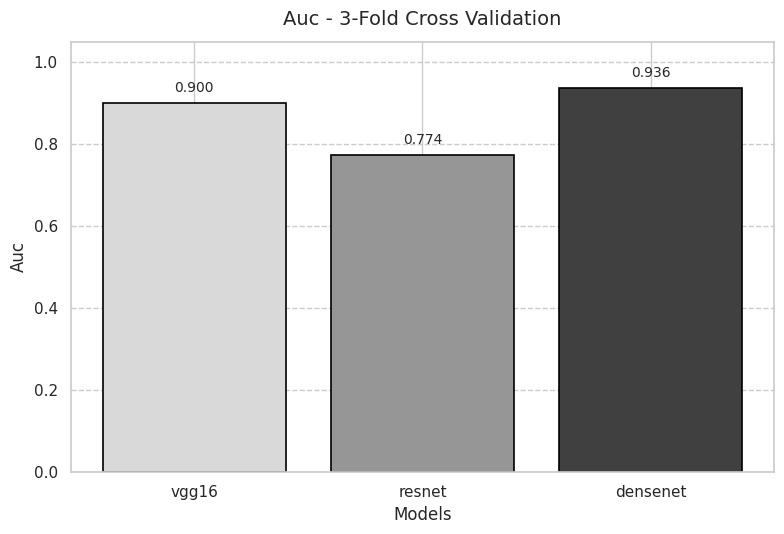

TABELLA RIASSUNTIVA DELLE MEDIE


,accuracy,sensitivity,specificity,f1,auc
model,,,,,
vgg16,0.8153,0.8688,0.7708,0.8102,0.8998
resnet,0.5465,0.0033,0.9979,0.0066,0.7741
densenet,0.8479,0.8454,0.8500,0.8346,0.9363


TABELLA RIASSUNTIVA COMPLETA


,model,fold,accuracy,sensitivity,specificity,f1,auc
0,densenet,1,0.8567,0.8596,0.8542,0.8448,0.9439
1,densenet,2,0.8487,0.8471,0.8500,0.8356,0.9354
2,densenet,3,0.8385,0.8296,0.8458,0.8234,0.9296
3,resnet,1,0.5461,0.0000,1.0000,0.0000,0.8078
4,resnet,2,0.5472,0.0075,0.9958,0.0149,0.7267
5,resnet,3,0.5461,0.0025,0.9979,0.0050,0.7878
6,vgg16,1,0.8123,0.8496,0.7812,0.8043,0.9015
7,vgg16,2,0.8259,0.8972,0.7667,0.8239,0.9002
8,vgg16,3,0.8077,0.8596,0.7646,0.8023,0.8978


/tmp/ipykernel_4696/2472425525.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


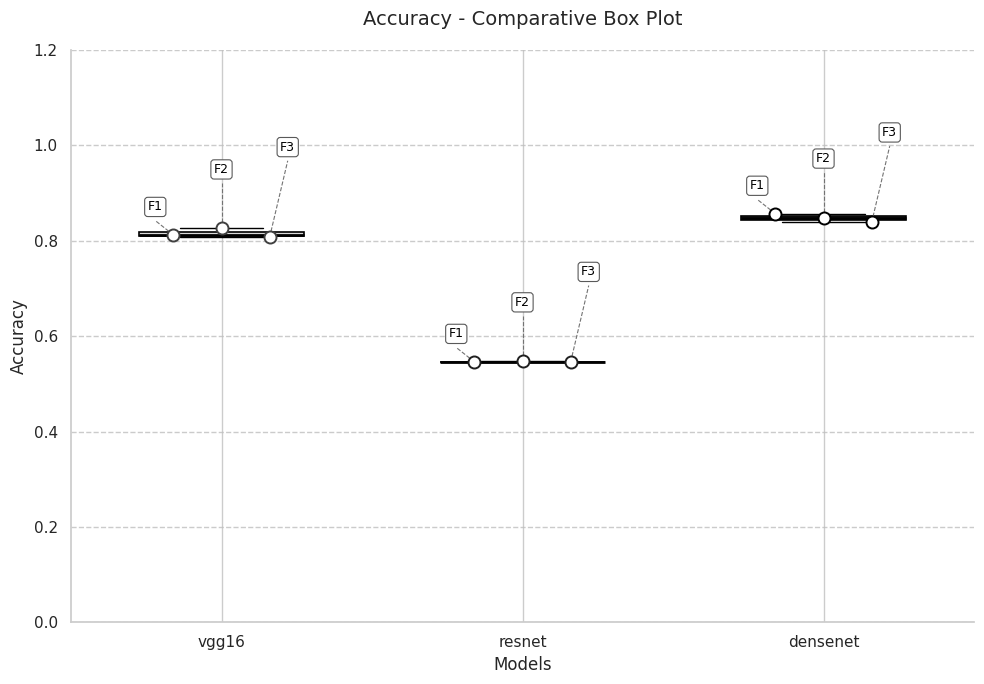

/tmp/ipykernel_4696/2472425525.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


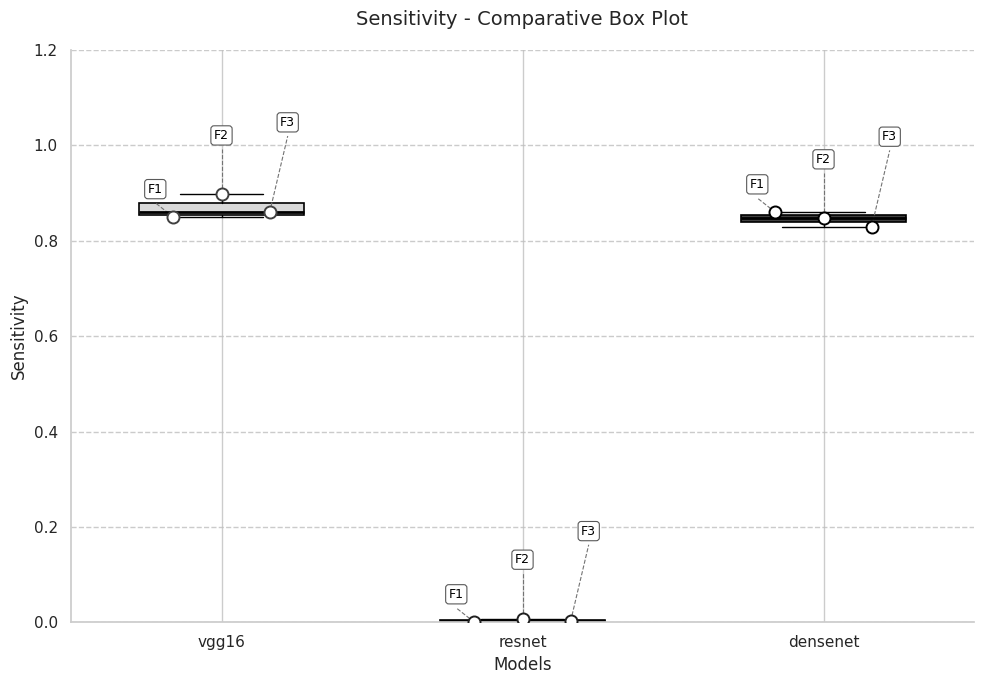

/tmp/ipykernel_4696/2472425525.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


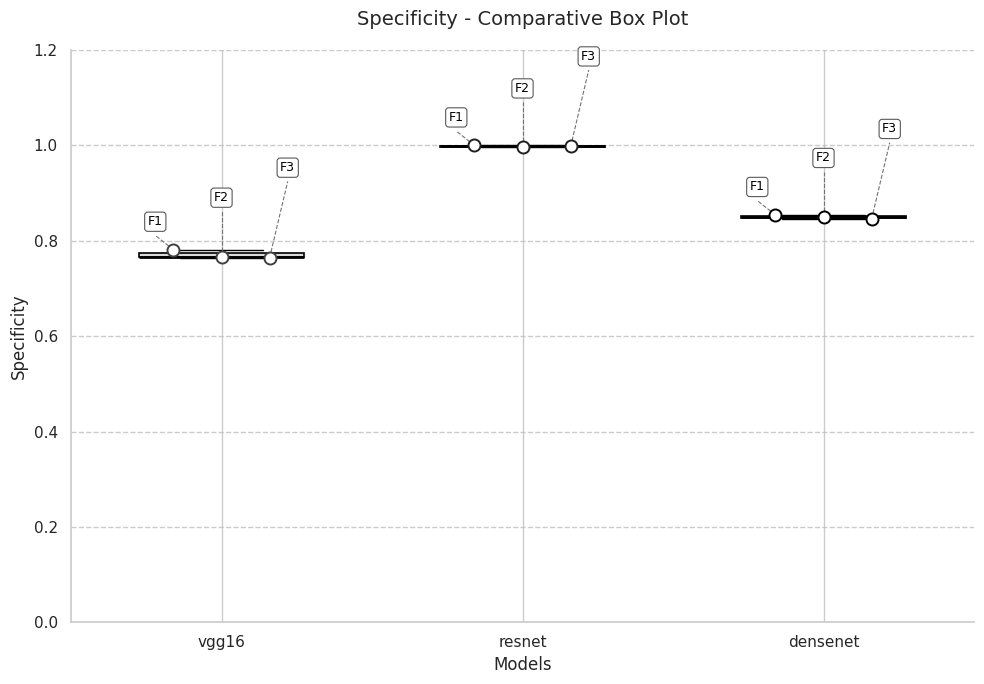

/tmp/ipykernel_4696/2472425525.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


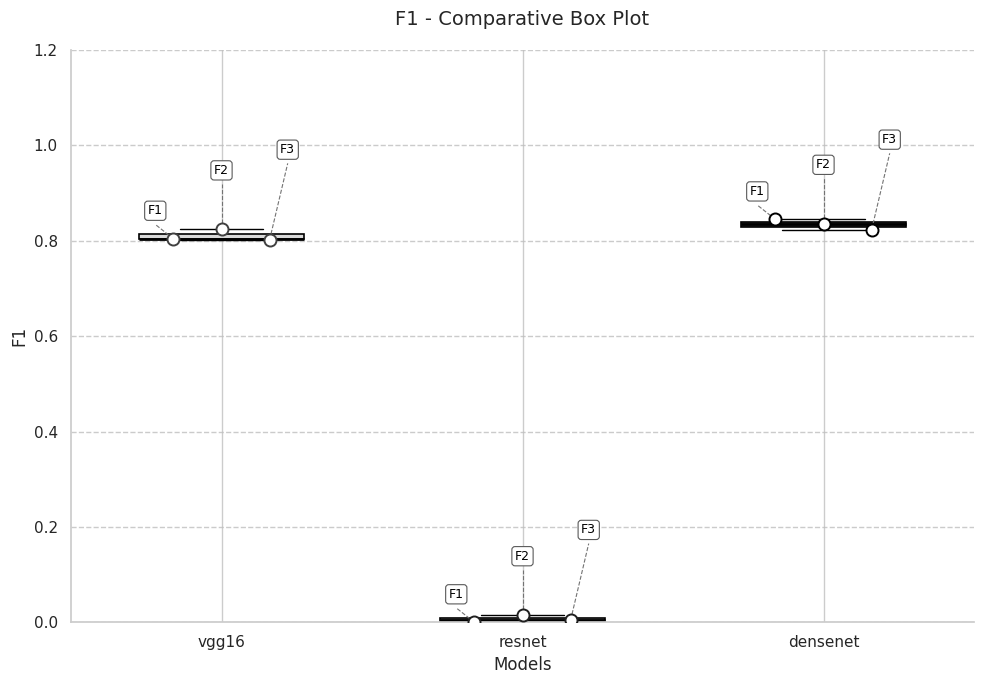

/tmp/ipykernel_4696/2472425525.py:289: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


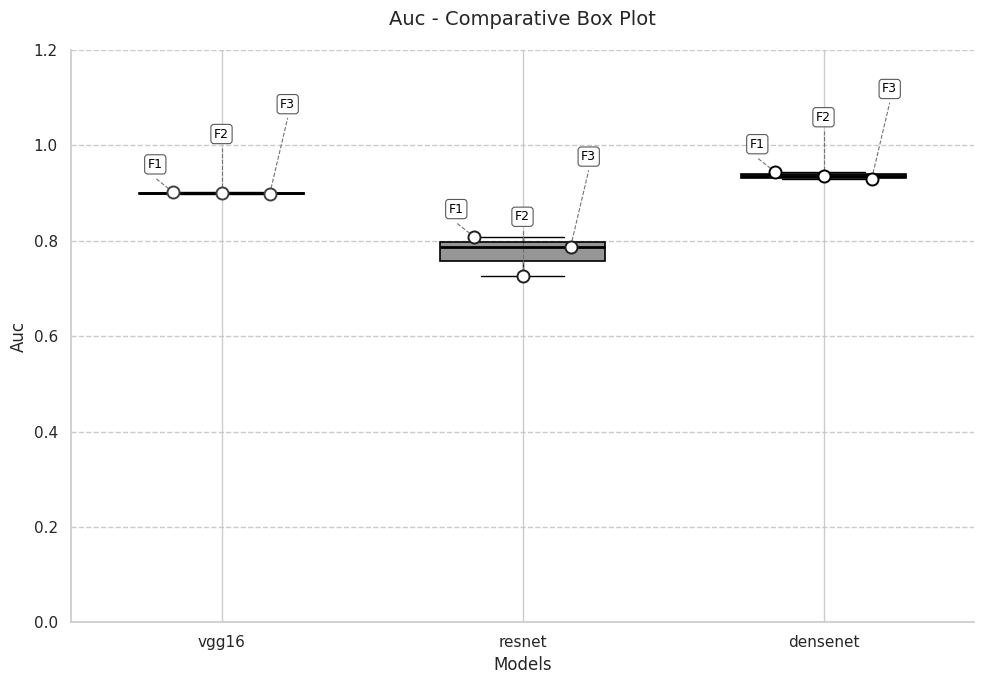

Elaborazione completata.
Grafici salvati in: /content/drive/MyDrive/CrossValidation/OldModels/plots/metrics
Tabella delle medie salvata in: /content/drive/MyDrive/CrossValidation/OldModels/metrics (2)/summary_means_by_model_and_metric.csv
Tabella completa salvata in: /content/drive/MyDrive/CrossValidation/OldModels/metrics (2)/complete_summary_by_fold_model_and_metric.csv


In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/CrossValidation/OldModels"

models = ["vgg16", "resnet", "densenet"]

metrics_to_plot = [
    "accuracy",
    "sensitivity",
    "specificity",
    "f1",
    "auc"
]

# Nome dei file contenenti i risultati dei singoli fold
fold_results_filename = "{}_3fold_cv_results.csv"

# Cartella corretta contenente i file CSV
metrics_path = os.path.join(BASE_PATH, "metrics (2)")

# Cartella di output dei grafici
plots_path = os.path.join(BASE_PATH, "plots", "metrics")

os.makedirs(plots_path, exist_ok=True)

# Scala di grigi adatta a una tesi e alla stampa
model_colors = {
    "vgg16": "#D9D9D9",
    "resnet": "#969696",
    "densenet": "#404040"
}

# Colori dei punti, sempre in scala di grigi
point_colors = {
    "vgg16": "#404040",
    "resnet": "#202020",
    "densenet": "#000000"
}


# CONTROLLO DELLA CARTELLA METRICS

if not os.path.exists(metrics_path):
    raise FileNotFoundError(
        f"La cartella delle metriche non esiste:\n{metrics_path}"
    )

print(f"Cartella utilizzata:\n{metrics_path}\n")


# CARICAMENTO DEI FILE SUMMARY

summary_dict = {}

for model in models:
    summary_path = os.path.join(
        metrics_path,
        f"{model}_3fold_cv_summary.csv"
    )

    if not os.path.exists(summary_path):
        raise FileNotFoundError(
            f"File summary non trovato:\n{summary_path}"
        )

    summary_dict[model] = pd.read_csv(
        summary_path,
        index_col=0
    )


# DataFrame contenente le medie
mean_df = pd.DataFrame({
    model: summary_dict[model].loc["mean"]
    for model in models
}).loc[metrics_to_plot]


# GRAFICI A BARRE DELLE MEDIE

for metric in metrics_to_plot:

    fig, ax = plt.subplots(figsize=(8, 5.5))

    means = [
        mean_df.loc[metric, model]
        for model in models
    ]

    bars = ax.bar(
        models,
        means,
        color=[model_colors[model] for model in models],
        edgecolor="black",
        linewidth=1.2
    )

    ax.set_title(
        f"{metric.capitalize()} - 3-Fold Cross Validation",
        fontsize=14,
        pad=12
    )

    ax.set_xlabel("Models", fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_ylim(0, 1.05)

    ax.tick_params(
        axis="both",
        labelsize=11
    )

    # Valore della media sopra ogni barra
    for bar, mean_value in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean_value + 0.02,
            f"{mean_value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10
        )

    ax.grid(
        axis="y",
        linestyle="--",
        color="0.75",
        alpha=0.8
    )

    ax.set_axisbelow(True)

    plt.tight_layout()

    save_path = os.path.join(
        plots_path,
        f"{metric}_cv_mean_comparison.png"
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# CARICAMENTO DEI RISULTATI DEI SINGOLI FOLD

fold_data = []

for model in models:

    fold_results_path = os.path.join(
        metrics_path,
        fold_results_filename.format(model)
    )

    if not os.path.exists(fold_results_path):
        raise FileNotFoundError(
            f"File dei risultati per-fold non trovato:\n"
            f"{fold_results_path}"
        )

    model_fold_df = pd.read_csv(fold_results_path)
    model_fold_df["model"] = model
    fold_data.append(model_fold_df)


complete_df = pd.concat(
    fold_data,
    ignore_index=True
)


# NORMALIZZAZIONE DELLA COLONNA FOLD

fold_column_candidates = [
    "fold",
    "Fold",
    "fold_id",
    "Fold_ID"
]

existing_fold_column = next(
    (
        column for column in fold_column_candidates
        if column in complete_df.columns
    ),
    None
)

if existing_fold_column is None:
    raise ValueError(
        "Colonna relativa al fold non trovata. "
        "Il CSV deve contenere 'fold', 'Fold' oppure 'fold_id'."
    )

if existing_fold_column != "fold":
    complete_df.rename(
        columns={existing_fold_column: "fold"},
        inplace=True
    )

# CONTROLLO DELLE METRICHE

missing_metrics = [
    metric for metric in metrics_to_plot
    if metric not in complete_df.columns
]

if missing_metrics:
    raise ValueError(
        f"Metriche mancanti nei file per-fold: {missing_metrics}"
    )


complete_df = complete_df[
    ["model", "fold"] + metrics_to_plot
].sort_values(
    by=["model", "fold"]
).reset_index(drop=True)


# TABELLA MEDIE

mean_table = (
    complete_df
    .groupby("model")[metrics_to_plot]
    .mean()
    .reindex(models)
    .round(4)
)

mean_table_path = os.path.join(
    metrics_path,
    "summary_means_by_model_and_metric.csv"
)

mean_table.to_csv(mean_table_path)

print("TABELLA RIASSUNTIVA DELLE MEDIE")
display(mean_table)

# TABELLA RIASSUNTIVA COMPLETA

complete_table_path = os.path.join(
    metrics_path,
    "complete_summary_by_fold_model_and_metric.csv"
)

complete_df_rounded = complete_df.copy()

complete_df_rounded[metrics_to_plot] = (
    complete_df_rounded[metrics_to_plot].round(4)
)

complete_df_rounded.to_csv(
    complete_table_path,
    index=False
)

print("TABELLA RIASSUNTIVA COMPLETA")
display(complete_df_rounded)


# BOX PLOT COMPARATIVO CON PUNTI DEI FOLD

rng = np.random.default_rng(42)

for metric in metrics_to_plot:

    fig, ax = plt.subplots(figsize=(10, 7))

    data_for_boxplot = [
        complete_df.loc[
            complete_df["model"] == model,
            metric
        ].dropna().values
        for model in models
    ]

    # Box plot
    box = ax.boxplot(
        data_for_boxplot,
        labels=models,
        patch_artist=True,
        widths=0.55,
        showfliers=False,
        medianprops={
            "color": "black",
            "linewidth": 2
        },
        whiskerprops={
            "color": "black",
            "linewidth": 1
        },
        capprops={
            "color": "black",
            "linewidth": 1
        },
        boxprops={
            "edgecolor": "black",
            "linewidth": 1.2
        }
    )

    # Riempimento dei box in scala di grigi
    for patch, model in zip(box["boxes"], models):
        patch.set_facecolor(model_colors[model])
        patch.set_alpha(1)

    # PUNTI E ANNOTAZIONI DEI SINGOLI FOLD

    for position, model in enumerate(models, start=1):

        model_rows = complete_df[
            complete_df["model"] == model
        ].dropna(
            subset=[metric]
        ).sort_values(
            by="fold"
        ).reset_index(drop=True)

        fold_values = model_rows[metric].to_numpy()

        # Jitter orizzontale ampio per separare i punti
        jitter = np.linspace(
            -0.16,
            0.16,
            len(fold_values)
        )

        x_points = position + jitter

        # Punti dei fold
        ax.scatter(
            x_points,
            fold_values,
            color="white",
            edgecolor=point_colors[model],
            linewidth=1.4,
            s=75,
            zorder=5
        )

        # Offset separati per le etichette
        horizontal_offsets = [-0.22, 0.0, 0.22]
        vertical_offsets = [0.045, 0.11, 0.175]

        for i, (x_point, (_, row)) in enumerate(
            zip(x_points, model_rows.iterrows())
        ):

            x_text = position + horizontal_offsets[i % 3]
            y_text = row[metric] + vertical_offsets[i % 3]

            # Linea tratteggiata tra punto ed etichetta
            ax.plot(
                [x_point, x_text],
                [row[metric], y_text - 0.015],
                linestyle="--",
                linewidth=0.8,
                color="0.45",
                zorder=2
            )

            # Etichetta del fold
            ax.text(
                x_text,
                y_text,
                f"F{int(row['fold'])}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="0.35",
                    linewidth=0.8
                ),
                zorder=6
            )

    # FORMATTAZIONE DEL GRAFICO
    ax.set_title(
        f"{metric.capitalize()} - Comparative Box Plot",
        fontsize=14,
        pad=18
    )

    ax.set_xlabel("Models", fontsize=12)
    ax.set_ylabel(metric.capitalize(), fontsize=12)

    # Spazio superiore per le etichette F1, F2 e F3
    ax.set_ylim(0, 1.20)

    ax.tick_params(
        axis="both",
        labelsize=11
    )

    ax.grid(
        axis="y",
        linestyle="--",
        color="0.75",
        alpha=0.8
    )

    ax.set_axisbelow(True)

    # Rimuove il bordo superiore e destro
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    boxplot_path = os.path.join(
        plots_path,
        f"{metric}_cv_boxplot_with_folds.png"
    )

    plt.savefig(
        boxplot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


print("Elaborazione completata.")
print(f"Grafici salvati in: {plots_path}")
print(f"Tabella delle medie salvata in: {mean_table_path}")
print(f"Tabella completa salvata in: {complete_table_path}")